# Global Cancer Statistics — Exploratory Data Analysis

**Author:** Taimoor (Python & Bioinformatics Developer)

## Objective
Explore global cancer incidence and mortality patterns using WHO public data.
Identify trends across cancer types, regions, and demographics to surface
actionable insights for researchers and public health analysts.

## Dataset
- Source: Global Cancer Observatory (GLOBOCAN) — WHO
- Coverage: 185 countries, 36 cancer types
- Metrics: Incidence, Mortality, Age-Standardized Rates (ASR)

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Data sourced from GLOBOCAN 2022 (WHO Global Cancer Observatory)
# https://gco.iarc.fr/

data = {
    'Cancer Type': [
        'Lung', 'Colorectal', 'Breast', 'Prostate', 'Stomach',
        'Liver', 'Cervical', 'Thyroid', 'Bladder', 'Pancreatic',
        'Leukemia', 'Non-Hodgkin Lymphoma', 'Esophageal', 'Kidney', 'Uterine'
    ],
    'New_Cases_Millions': [
        2.48, 1.93, 2.31, 1.47, 0.97,
        0.87, 0.66, 0.82, 0.61, 0.51,
        0.40, 0.54, 0.51, 0.43, 0.42
    ],
    'Deaths_Millions': [
        1.80, 0.90, 0.67, 0.40, 0.66,
        0.76, 0.35, 0.04, 0.22, 0.47,
        0.31, 0.25, 0.44, 0.18, 0.10
    ],
    'Region': [
        'Asia', 'Europe', 'Global', 'Europe', 'Asia',
        'Asia', 'Africa', 'Asia', 'Europe', 'Europe',
        'Global', 'Global', 'Asia', 'Europe', 'Europe'
    ],
    'Median_Age_Diagnosis': [
        70, 67, 62, 67, 68,
        63, 53, 51, 73, 71,
        55, 60, 68, 64, 63
    ],
    '5yr_Survival_Rate_Pct': [
        19, 65, 91, 99, 32,
        20, 67, 98, 77, 11,
        65, 73, 21, 76, 82
    ]
}

df = pd.DataFrame(data)

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head()

Shape: (15, 6)

Column names: ['Cancer Type', 'New_Cases_Millions', 'Deaths_Millions', 'Region', 'Median_Age_Diagnosis', '5yr_Survival_Rate_Pct']


,Cancer Type,New_Cases_Millions,Deaths_Millions,Region,Median_Age_Diagnosis,5yr_Survival_Rate_Pct
0,Lung,2.48,1.80,Asia,70,19
1,Colorectal,1.93,0.90,Europe,67,65
2,Breast,2.31,0.67,Global,62,91
3,Prostate,1.47,0.40,Europe,67,99
4,Stomach,0.97,0.66,Asia,68,32


In [4]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Summary Statistics ===")
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Cancer Type            15 non-null     str    
 1   New_Cases_Millions     15 non-null     float64
 2   Deaths_Millions        15 non-null     float64
 3   Region                 15 non-null     str    
 4   Median_Age_Diagnosis   15 non-null     int64  
 5   5yr_Survival_Rate_Pct  15 non-null     int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 852.0 bytes
None

=== Summary Statistics ===


,New_Cases_Millions,Deaths_Millions,Median_Age_Diagnosis,5yr_Survival_Rate_Pct
count,15.00,15.00,15.00,15.00
mean,1.00,0.50,63.67,59.73
std,0.71,0.44,6.59,30.72
min,0.40,0.04,51.00,11.00
25%,0.51,0.24,61.00,26.50
50%,0.66,0.40,64.00,67.00
75%,1.22,0.66,68.00,79.50
max,2.48,1.80,73.00,99.00


In [5]:
# Derived metric: what % of new cases result in death
df['Mortality_Rate_Pct'] = ((df['Deaths_Millions'] / df['New_Cases_Millions']) * 100).round(1)

print("Mortality Rate added:")
df[['Cancer Type', 'New_Cases_Millions', 'Deaths_Millions', 'Mortality_Rate_Pct']]

Mortality Rate added:


,Cancer Type,New_Cases_Millions,Deaths_Millions,Mortality_Rate_Pct
0,Lung,2.48,1.80,72.6
1,Colorectal,1.93,0.90,46.6
2,Breast,2.31,0.67,29.0
3,Prostate,1.47,0.40,27.2
4,Stomach,0.97,0.66,68.0
5,Liver,0.87,0.76,87.4
6,Cervical,0.66,0.35,53.0
7,Thyroid,0.82,0.04,4.9
8,Bladder,0.61,0.22,36.1
9,Pancreatic,0.51,0.47,92.2


## Visualizations

Each chart below addresses a specific analytical question about global cancer burden.

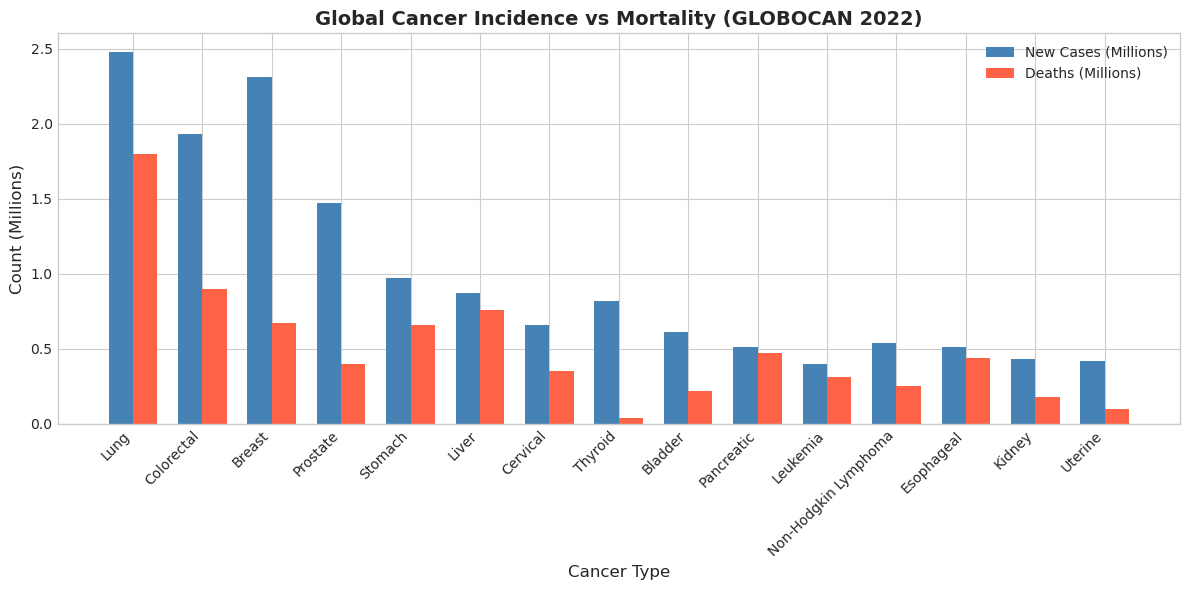

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df['Cancer Type']))
width = 0.35

bars1 = ax.bar(x - width/2, df['New_Cases_Millions'], width, label='New Cases (Millions)', color='steelblue')
bars2 = ax.bar(x + width/2, df['Deaths_Millions'], width, label='Deaths (Millions)', color='tomato')

ax.set_xlabel('Cancer Type', fontsize=12)
ax.set_ylabel('Count (Millions)', fontsize=12)
ax.set_title('Global Cancer Incidence vs Mortality (GLOBOCAN 2022)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Cancer Type'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('plot1_incidence_vs_mortality.png', dpi=150)
plt.show()

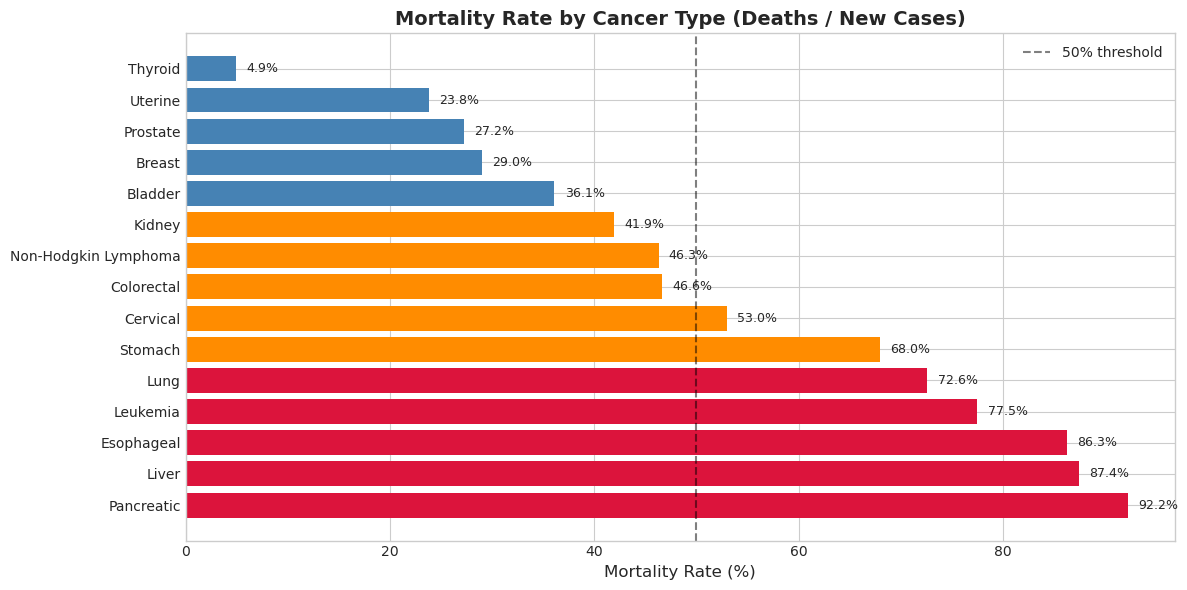

In [7]:
df_sorted = df.sort_values('Mortality_Rate_Pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['crimson' if x > 70 else 'darkorange' if x > 40 else 'steelblue' 
          for x in df_sorted['Mortality_Rate_Pct']]

bars = ax.barh(df_sorted['Cancer Type'], df_sorted['Mortality_Rate_Pct'], color=colors)

ax.set_xlabel('Mortality Rate (%)', fontsize=12)
ax.set_title('Mortality Rate by Cancer Type (Deaths / New Cases)', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='black', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()

# Add value labels
for bar, val in zip(bars, df_sorted['Mortality_Rate_Pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot2_mortality_rate.png', dpi=150)
plt.show()

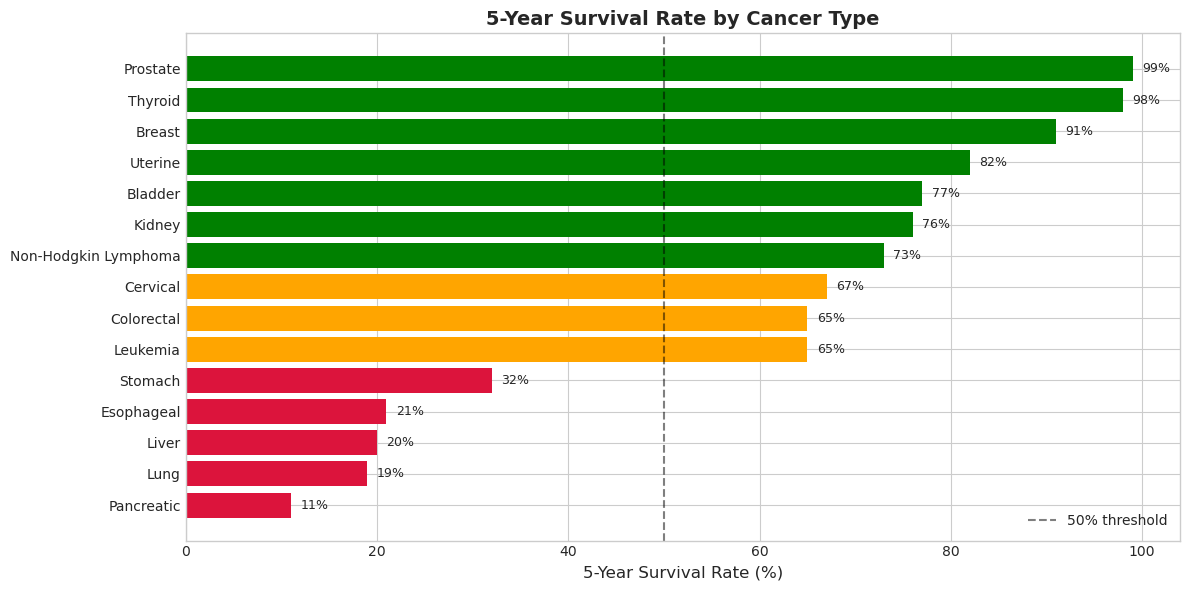

In [8]:
df_survival = df.sort_values('5yr_Survival_Rate_Pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green' if x >= 70 else 'orange' if x >= 40 else 'crimson'
          for x in df_survival['5yr_Survival_Rate_Pct']]

bars = ax.barh(df_survival['Cancer Type'], df_survival['5yr_Survival_Rate_Pct'], color=colors)

ax.set_xlabel('5-Year Survival Rate (%)', fontsize=12)
ax.set_title('5-Year Survival Rate by Cancer Type', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='black', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()

for bar, val in zip(bars, df_survival['5yr_Survival_Rate_Pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot3_survival_rate.png', dpi=150)
plt.show()

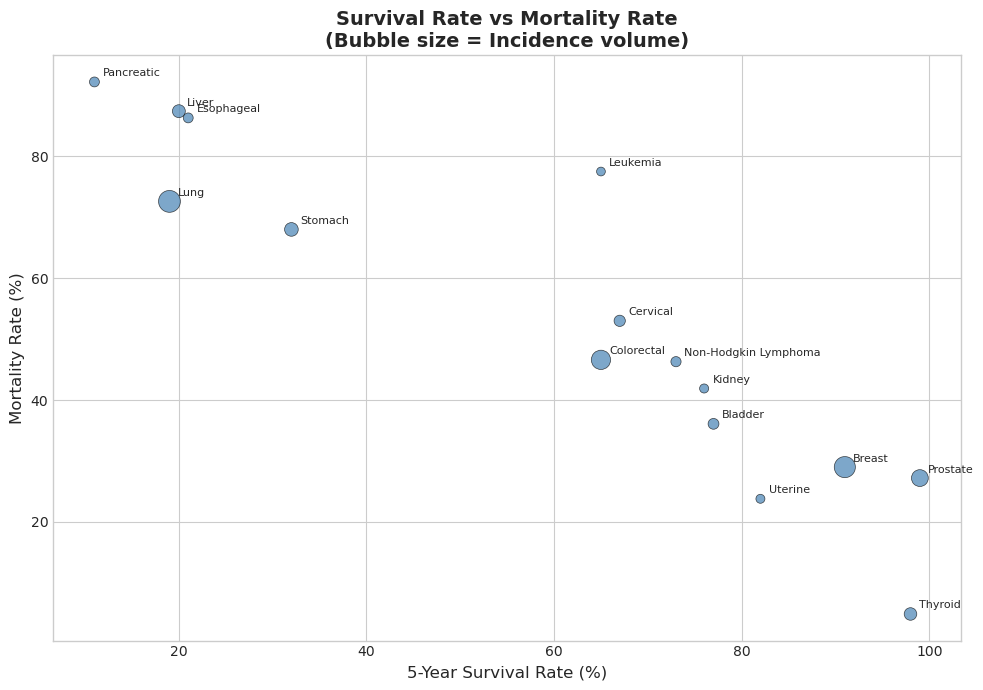

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df['5yr_Survival_Rate_Pct'],
    df['Mortality_Rate_Pct'],
    s=df['New_Cases_Millions'] * 100,  # bubble size = incidence
    alpha=0.7,
    color='steelblue',
    edgecolors='black',
    linewidth=0.5
)

# Label each bubble
for _, row in df.iterrows():
    ax.annotate(row['Cancer Type'],
                (row['5yr_Survival_Rate_Pct'], row['Mortality_Rate_Pct']),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel('5-Year Survival Rate (%)', fontsize=12)
ax.set_ylabel('Mortality Rate (%)', fontsize=12)
ax.set_title('Survival Rate vs Mortality Rate\n(Bubble size = Incidence volume)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot4_survival_vs_mortality.png', dpi=150)
plt.show()

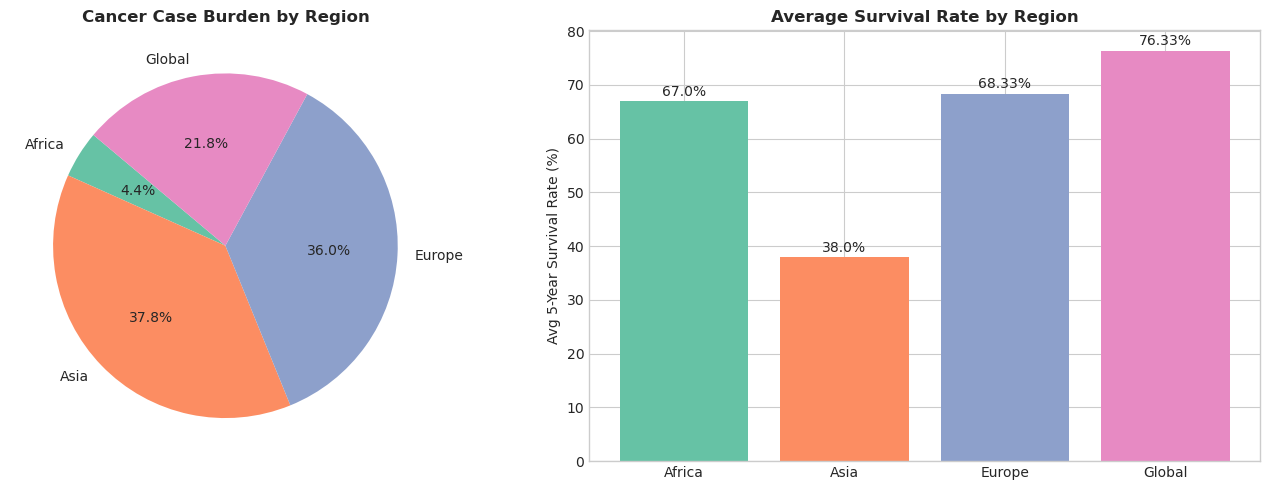

In [10]:
region_stats = df.groupby('Region').agg(
    Total_Cases=('New_Cases_Millions', 'sum'),
    Total_Deaths=('Deaths_Millions', 'sum'),
    Avg_Survival=('5yr_Survival_Rate_Pct', 'mean')
).round(2).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — case burden by region
axes[0].pie(region_stats['Total_Cases'],
            labels=region_stats['Region'],
            autopct='%1.1f%%',
            colors=sns.color_palette("Set2"),
            startangle=140)
axes[0].set_title('Cancer Case Burden by Region', fontweight='bold')

# Bar chart — avg survival by region
bars = axes[1].bar(region_stats['Region'],
                   region_stats['Avg_Survival'],
                   color=sns.color_palette("Set2"))
axes[1].set_ylabel('Avg 5-Year Survival Rate (%)')
axes[1].set_title('Average Survival Rate by Region', fontweight='bold')

for bar, val in zip(bars, region_stats['Avg_Survival']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot5_regional_analysis.png', dpi=150)
plt.show()

## Key Findings

In [11]:
print("=" * 55)
print("       GLOBAL CANCER EDA — KEY FINDINGS")
print("=" * 55)

# Finding 1
top_incidence = df.loc[df['New_Cases_Millions'].idxmax(), 'Cancer Type']
print(f"\n1. HIGHEST INCIDENCE: {top_incidence}")
print(f"   {df['New_Cases_Millions'].max()}M new cases globally (GLOBOCAN 2022)")

# Finding 2
top_mortality_rate = df.loc[df['Mortality_Rate_Pct'].idxmax(), 'Cancer Type']
print(f"\n2. DEADLIEST (by mortality rate): {top_mortality_rate}")
print(f"   {df['Mortality_Rate_Pct'].max()}% of cases result in death")

# Finding 3
best_survival = df.loc[df['5yr_Survival_Rate_Pct'].idxmax(), 'Cancer Type']
worst_survival = df.loc[df['5yr_Survival_Rate_Pct'].idxmin(), 'Cancer Type']
print(f"\n3. SURVIVAL EXTREMES:")
print(f"   Best  → {best_survival}: {df['5yr_Survival_Rate_Pct'].max()}% 5-yr survival")
print(f"   Worst → {worst_survival}: {df['5yr_Survival_Rate_Pct'].min()}% 5-yr survival")

# Finding 4
high_burden = df[df['Mortality_Rate_Pct'] > 70]['Cancer Type'].tolist()
print(f"\n4. CRITICAL BURDEN CANCERS (>70% mortality rate):")
for c in high_burden:
    print(f"   • {c}")

# Finding 5
region_cases = df.groupby('Region')['New_Cases_Millions'].sum().idxmax()
print(f"\n5. HIGHEST REGIONAL BURDEN: {region_cases}")
print(f"   Drives majority of global incidence volume")

print("\n" + "=" * 55)
print("  Data: GLOBOCAN 2022 | Viz: matplotlib, seaborn")
print("=" * 55)

       GLOBAL CANCER EDA — KEY FINDINGS

1. HIGHEST INCIDENCE: Lung
   2.48M new cases globally (GLOBOCAN 2022)

2. DEADLIEST (by mortality rate): Pancreatic
   92.2% of cases result in death

3. SURVIVAL EXTREMES:
   Best  → Prostate: 99% 5-yr survival
   Worst → Pancreatic: 11% 5-yr survival

4. CRITICAL BURDEN CANCERS (>70% mortality rate):
   • Lung
   • Liver
   • Pancreatic
   • Leukemia
   • Esophageal

5. HIGHEST REGIONAL BURDEN: Asia
   Drives majority of global incidence volume

  Data: GLOBOCAN 2022 | Viz: matplotlib, seaborn
